# Medical Image Preprocessing - Filtering

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import random

In [ ]:
image_paths = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".jpg"):
            image_paths.append(os.path.join(root, file))

print("Total images:", len(image_paths))

Total images found: 20030


In [53]:
import random
sample_paths = random.sample(image_paths, 10)

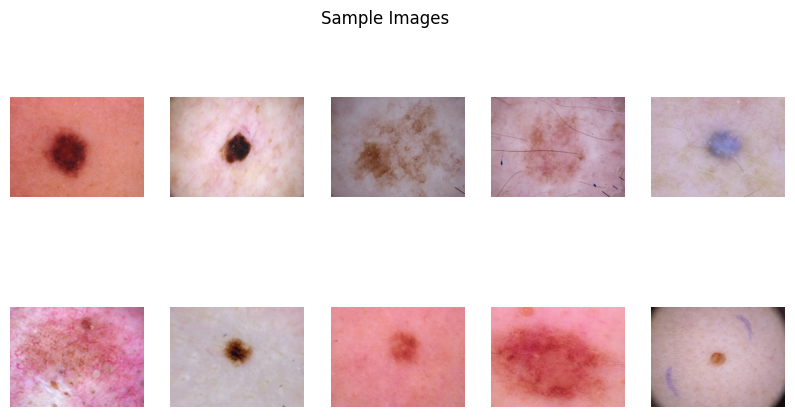

In [54]:
plt.figure(figsize=(10,5))

for i, path in enumerate(sample_paths):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.axis('off')

plt.suptitle("Sample Images")
plt.show()

## Single Image Experiment

(np.float64(-0.5), np.float64(599.5), np.float64(449.5), np.float64(-0.5))

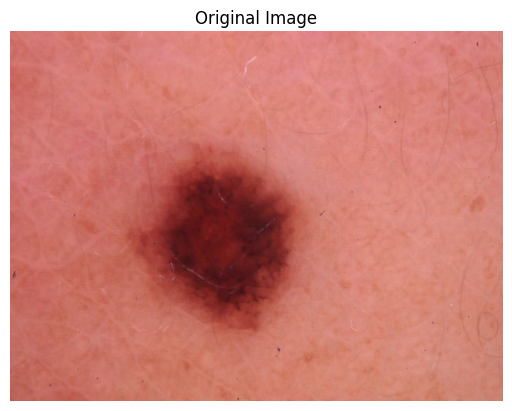

In [ ]:
# Read image
img = cv2.imread(sample_paths[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display original image
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

(np.float64(-0.5), np.float64(599.5), np.float64(449.5), np.float64(-0.5))

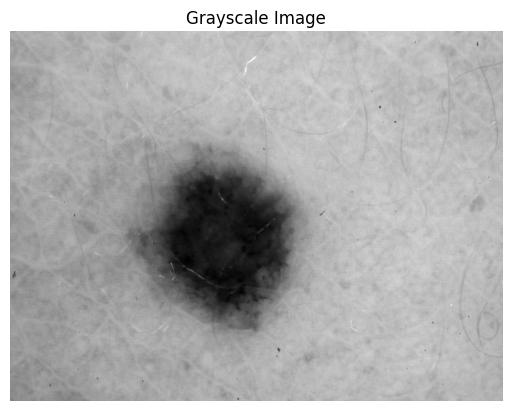

In [ ]:
# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

(np.float64(-0.5), np.float64(599.5), np.float64(449.5), np.float64(-0.5))

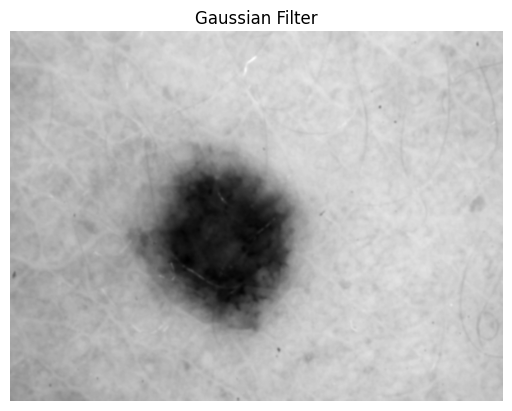

In [ ]:
# Apply Gaussian filter
gaussian = cv2.GaussianBlur(gray, (5,5), 0)

plt.imshow(gaussian, cmap='gray')
plt.title("Gaussian Filter")
plt.axis('off')

(np.float64(-0.5), np.float64(599.5), np.float64(449.5), np.float64(-0.5))

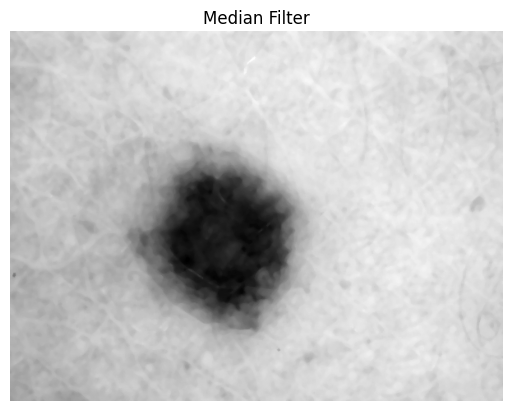

In [ ]:
# Apply Median filter
median = cv2.medianBlur(gray, 5)

plt.imshow(median, cmap='gray')
plt.title("Median Filter")
plt.axis('off')

## Comparison Between Filters

- Gaussian Filter smooths the image but may blur edges.
- Median Filter is better at removing noise while preserving edges.

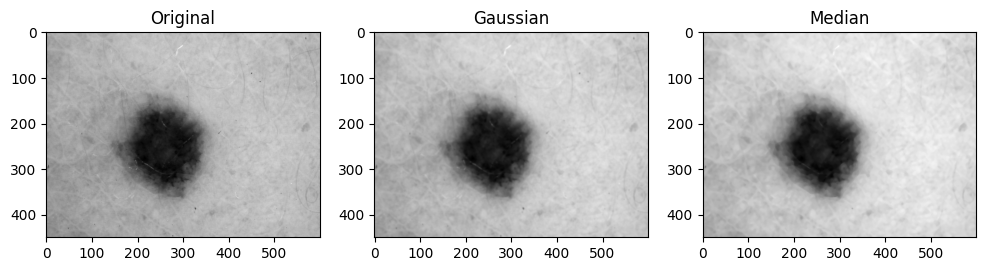

In [ ]:
# Compare filters
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(gaussian, cmap='gray')
plt.title("Gaussian")

plt.subplot(1,3,3)
plt.imshow(median, cmap='gray')
plt.title("Median")

plt.show()

## Observations

- Gaussian filter smooths the image effectively.
- Median filter preserves edges better.

## Noise Experiment

We add Gaussian noise to the image and evaluate how each filter performs.

In [ ]:
# Take one image for noise experiment
img = cv2.imread(sample_paths[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

(np.float64(-0.5), np.float64(599.5), np.float64(449.5), np.float64(-0.5))

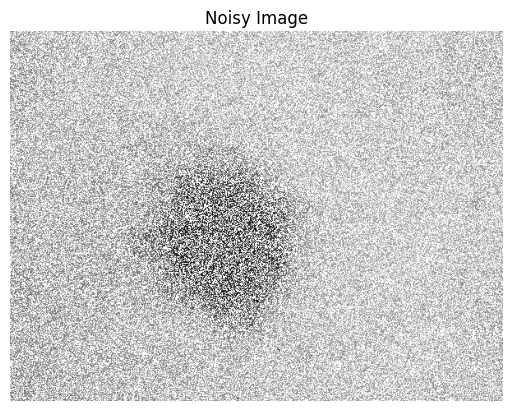

In [ ]:
# Add noise
noise = np.random.normal(0, 25, gray.shape)
noisy = gray + noise
noisy = np.clip(noisy, 0, 255).astype(np.uint8)


plt.imshow(noisy, cmap='gray')
plt.title("Noisy Image")
plt.axis('off')

In [ ]:
# Apply filters on noisy image
gaussian_noisy = cv2.GaussianBlur(noisy, (5,5), 0)
median_noisy = cv2.medianBlur(noisy, 5)

## Noise Analysis

- Gaussian filter reduces Gaussian noise effectively.
- Median filter is less effective for this type of noise.
- Median works better for salt-and-pepper noise.

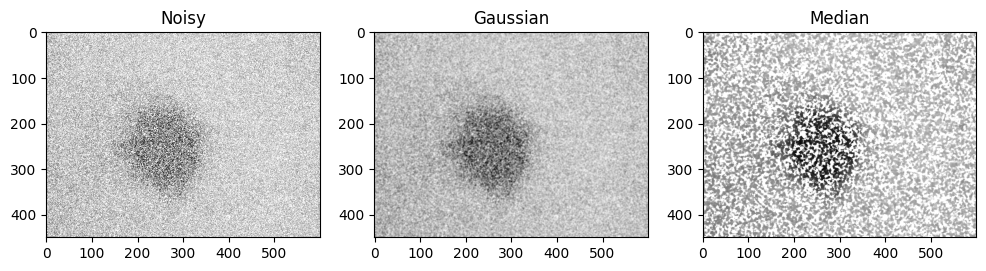

In [ ]:
# Compare results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy")

plt.subplot(1,3,2)
plt.imshow(gaussian_noisy, cmap='gray')
plt.title("Gaussian")

plt.subplot(1,3,3)
plt.imshow(median_noisy, cmap='gray')
plt.title("Median")

plt.show()

## Applying Filters on Multiple Images

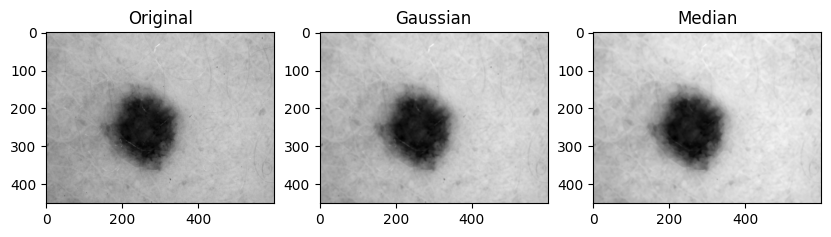

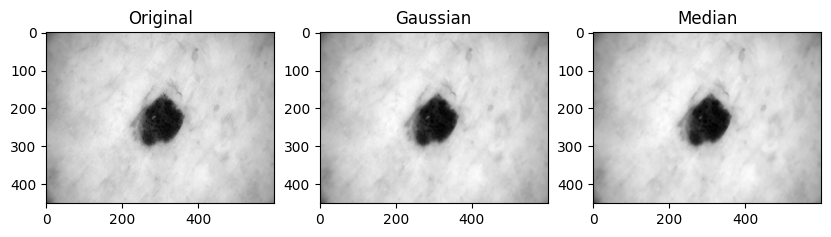

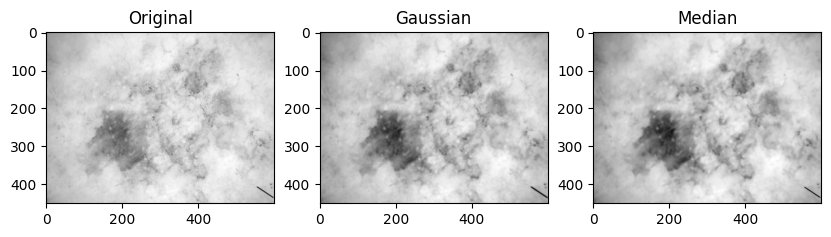

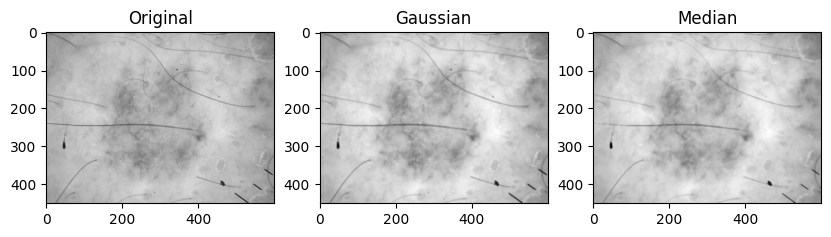

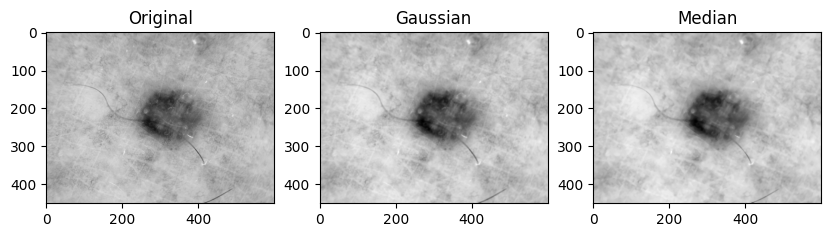

In [ ]:
for i, path in enumerate(sample_paths[:5]):
    
    # Read image
    img = cv2.imread(path)
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply filters
    gaussian = cv2.GaussianBlur(gray, (5,5), 0)
    median = cv2.medianBlur(gray, 5)
    
    # Display results
    plt.figure(figsize=(10,3))
    
    plt.subplot(1,3,1)
    plt.imshow(gray, cmap='gray')
    plt.title("Original")
    
    plt.subplot(1,3,2)
    plt.imshow(gaussian, cmap='gray')
    plt.title("Gaussian")
    
    plt.subplot(1,3,3)
    plt.imshow(median, cmap='gray')
    plt.title("Median")
    
    plt.show()

## Final Observations

- Gaussian filter is effective for smoothing and reducing Gaussian noise.
- Median filter is better at preserving edges.
- Filter performance depends on the type of noise.